In [ ]:
import xarray as xr 
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import matplotlib.dates as mdates
import numpy as np 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cmocean as cmo
import matplotlib.dates as mdates
import os 
import xarray as xr 
import datetime
from datetime import datetime, timedelta


ds = xr.open_dataset("hydro.nc", decode_times=False)
print(ds)
nt = len(ds.time) - 1
z = ds.z.values

# ds = ds.isel(time=slice(15, nt))

nt = len(ds.time) - 1

# Load adv data
adv = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/data/usgs/eps_shear_tke.csv", parse_dates=['time'], index_col='time')
adv.dropna(inplace=True, how='all')
print(adv)


<xarray.Dataset> Size: 10MB
Dimensions:  (time: 2880, z: 50)
Coordinates:
  * time     (time) float32 12kB 0.0 145.0 295.0 ... 4.317e+05 4.318e+05
  * z        (z) float32 200B 3.96 3.88 3.8 3.72 3.64 ... 0.28 0.2 0.12 0.04
Data variables:
    U        (time, z) float64 1MB ...
    Kq       (time, z) float64 1MB ...
    Nu       (time, z) float64 1MB ...
    C        (time, z) float64 1MB ...
    Kz       (time, z) float64 1MB ...
    L        (time, z) float64 1MB ...
    Q2       (time, z) float64 1MB ...
    Q2L      (time, z) float64 1MB ...
    N_BV2    (time, z) float64 1MB ...
Attributes:
    title:    testing
                                  eps     shear       tke
time                                                     
2020-07-16 20:10:01.000           NaN       NaN  0.020735
2020-07-16 20:15:01.062           NaN       NaN  0.020707
2020-07-16 20:20:01.125           NaN       NaN  0.020731
2020-07-16 20:25:01.187           NaN       NaN  0.020840
2020-07-16 20:30:01.249    

In [ ]:
import pandas as pd 

adv = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/data/usgs/eps_shear_tke.csv", parse_dates=['time'], index_col='time')
adv.dropna(inplace=True, how='all')
print(adv)



adv_shear = adv.copy()

# adv_shear = adv_shear.iloc[0: 280]
# print(adv_shear)
adv_shear = adv_shear.resample('1s').mean()
adv_shear = adv_shear.interpolate(method='linear', limit_direction='both')

# Apply moving average
smoothed= adv_shear.rolling(window=500, center=True).mean()
adv['smoothed_shear'] = smoothed['shear']

adv_shear['seconds'] = (adv_shear.index - adv_shear.index[0]).total_seconds()

fig = plt.figure(figsize=(10, 5))
ax = plt.gca()
ax.plot(adv_shear.seconds, adv_shear.shear, color='k', alpha=0.5, label="Original shear")
ax.plot(adv_shear.seconds, adv_shear.smoothed_shear, color='r', label="Smoothed shear")
ax.set_xlabel("Time (s)")
# adv_shear.to_csv("adv_shear_4_model.csv")

                                  eps     shear       tke
time                                                     
2020-07-16 20:10:01.000           NaN       NaN  0.020735
2020-07-16 20:15:01.062           NaN       NaN  0.020707
2020-07-16 20:20:01.125           NaN       NaN  0.020731
2020-07-16 20:25:01.187           NaN       NaN  0.020840
2020-07-16 20:30:01.249           NaN       NaN  0.020764
...                               ...       ...       ...
2020-07-30 15:19:09.312  1.363502e-06  1.167691  0.020934
2020-07-30 15:24:09.375  1.549964e-05  3.936958  0.020665
2020-07-30 15:29:09.437           NaN       NaN  0.020708
2020-07-30 15:34:09.500  5.532728e-08  0.235218  0.020762
2020-07-30 15:39:09.562  2.737240e-06  1.654461  0.020777

[3978 rows x 3 columns]


In [ ]:
# Load in ADCP data
adcp = xr.open_dataset("/global/homes/s/siennaw/scratch/siennaw/data/usgs/resampled_adcp_usgs.nc") #, decode_times=False)

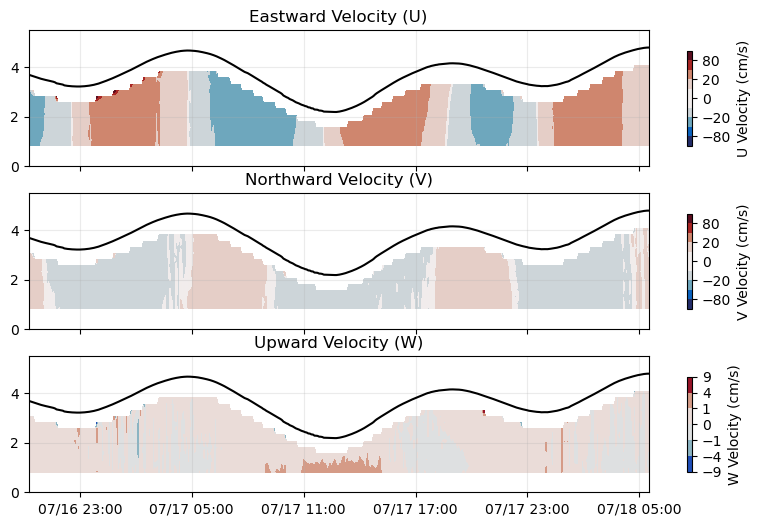

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

low, high = 0, 400
rtime = adcp.time.values[low:high]

offset= 3.537306921274909


axs[0].set_xlim(rtime[0], rtime[-1])
levels = [-100, -80, -50, -20, -1, 0, 1, 20, 50, 80, 100]

velocity = np.squeeze(adcp.u_1205)
z = adcp.depth.values
h = axs[0].contourf(rtime, -z + offset, velocity[low:high,:].T, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='U Velocity (cm/s)', shrink=0.7)
axs[0].set_title('Eastward Velocity (U)')

def format_date_ax(ax, int=1):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=int))
    date_format = mdates.DateFormatter('%m/%d %H:%M')
    ax.xaxis.set_major_formatter(date_format)


depths =  np.squeeze(adcp.P_1.values[low:high]) #+ 0.41

axs[0].plot(rtime, depths, color='k', label='Depth')
axs[1].plot(rtime, depths, color='k', label='Depth')
axs[2].plot(rtime, depths, color='k', label='Depth')

velocity = np.squeeze(adcp.v_1206)
h = axs[1].contourf(rtime, -z + offset, velocity[low:high,:].T,  cmap=cmo.cm.balance, levels=levels)

plt.colorbar(h, label='V Velocity (cm/s)', shrink=0.7)
axs[1].set_title('Northward Velocity (V)')

vmin, vmax = -10, 10
velocity = np.squeeze(adcp.w_1204)

levels = [-9, -4, -1, 0, 1, 4, 9]
h = axs[2].contourf(rtime, -z + offset, velocity[low:high,:].T, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='W Velocity (cm/s)', shrink=0.7)
axs[2].set_title('Upward Velocity (W)')

for ax in axs:
    ax.grid(alpha=0.25)
    format_date_ax(ax, int=6)
    ax.set_ylim(0, 5.5)


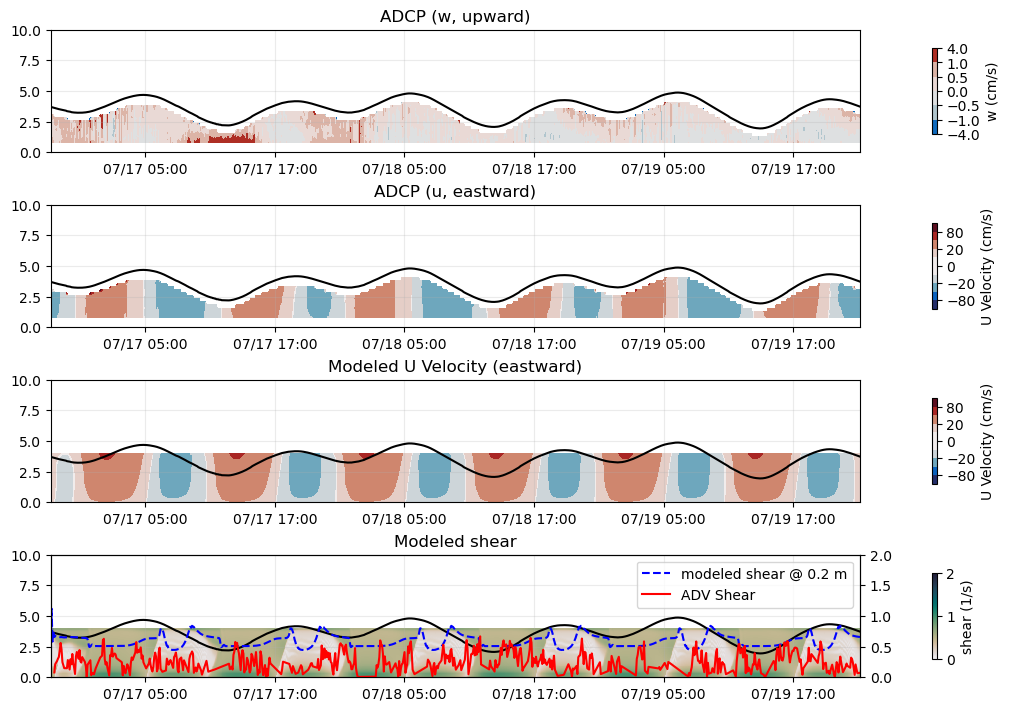

In [ ]:
fig, axs = plt.subplots(4, 1, figsize=(10, 7), sharex=False, constrained_layout=True)

low, high = 0, 900
rtime = adcp.time.values[low:high]

#                                 # blanking distance         
depths =  np.squeeze(adcp.P_1.values[low:high])  

levels = [-100, -80, -50, -20, -1, 0, 1, 20, 50, 80, 100]

velocity = np.squeeze(adcp.u_1205)
velocity = velocity[low:high,:].T
z = adcp.depth.values
h = axs[1].contourf(rtime, offset-z, velocity, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='U Velocity (cm/s)', shrink=0.7)
axs[1].set_title('ADCP (u, eastward)')


velocity = np.squeeze(adcp.w_1204)
levelsW = [-4, -1, -0.5, 0, 0.5, 1, 4]
h = axs[0].contourf(rtime, offset-z, velocity[low:high,:].T, cmap=cmo.cm.balance, levels=levelsW)
plt.colorbar(h, label='w (cm/s)', shrink=0.7)
axs[0].set_title('ADCP (w, upward)')


model_time = [pd.to_datetime(rtime[0]) + pd.Timedelta(seconds=j) for j in ds.time.values]

axs[2].set_title("Modeled U Velocity (eastward)")
h = axs[2].contourf(model_time, 4-ds.z, ds.U.T*100, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='U Velocity (cm/s)', shrink=0.7)

axs[3].set_title("Modeled shear")
shear = np.sqrt((ds.Q2 /ds.Kz)) 
ax2 = axs[3].twinx()
ax2.plot(model_time, shear.sel(z=0.1, method='nearest').values, '--', color='b', label='modeled shear @ 0.2 m')
ax2.set_ylim(0, 2)

# adv_shear = adv.shear.dropna()
# ax2.plot(adv_shear/10, color='r', label='ADV Shear')
# ax2.legend()
# h = axs[3].pcolormesh(model_time, 4-ds.z, shear.T, cmap=cmo.cm.rain, vmin=0, vmax=2)
# ax2.set_ylabel('shear (1/s)')
# h = axs[3].pcolormesh(model_time, 4-ds.z, ds.C.T, cmap=cmo.cm.rain, vmin=20, vmax=25)

# h = axs[3].pcolormesh(model_time, ds.z, np.log(ds.Q2.T), cmap=cmo.cm.rain, vmin=-8, vmax=-2)
plt.colorbar(h, label='shear (1/s)', shrink=0.7)

for ax in axs:
    ax.plot(rtime, depths, color='k', label='Depth')
    ax.grid(alpha=0.25)
    format_date_ax(ax, int=12)
    ax.set_xlim(rtime[0], rtime[-1])
    ax.set_ylim(0, 10)
    ax.set_ylabel('Depth (m)')
# plt.tight_layout()



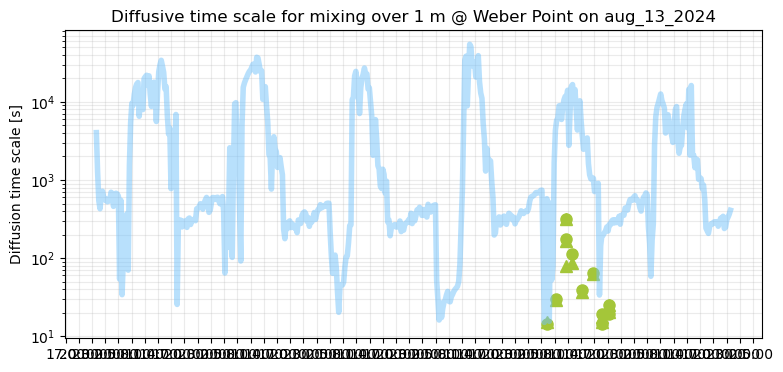

In [ ]:
fig2 = plt.figure(figsize=(9,4))
ax2 = plt.gca()
ax2.plot(t, np.sqrt(1/k1), 'o', color=colors[0], markersize=8, label="MicroCTD $T_{\epsilon}$")
ax2.plot(t, np.sqrt(1/k2), '^', color=colors[0], markersize=8, label="MicroCTD $T_{\epsilon}$")
ax2.plot(dates, 1/kz_av, linewidth=4, alpha=0.5, color=colors[1], label="One-dimension modeled $\kappa$")

# ax2.hlines(1/(diatom), t[0], t[-1], color=colors[2], label="1.4e-5 m/s", linestyle="--")
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax2.grid(alpha=0.25, which="both")
# ax2.set_xlim(dates[175], dates[220])
ax2.set_yscale('log')
ax2.set_ylabel("Diffusion time scale [s]")
ax2.set_ylabel("Diffusion time scale [s]")
ax2.set_title("Diffusive time scale for mixing over 1 m @ Weber Point on %s" % date)
fig.savefig("aug_27.png")